#STEP 1: Import Libraries


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


#STEP 2: Load Dataset


In [29]:
df = pd.read_csv(r"Titanic-Dataset.csv")

print("="*50)
print("DATASET SHAPE")
print("="*50)
print(df.shape)

print("\nFIRST 5 ROWS")
print(df.head())


DATASET SHAPE
(891, 12)

FIRST 5 ROWS
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0         

#STEP 3: Dataset Information


In [30]:
print("\n" + "="*50)
print("DATASET INFORMATION")
print("="*50)
print(df.info())

print("\nMISSING VALUES")
print(df.isnull().sum())



DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

MISSING VALUES
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin       

#STEP 4: Statistical Summary


In [31]:
print("\n" + "="*50)
print("STATISTICAL SUMMARY")
print("="*50)
print(df.describe())



STATISTICAL SUMMARY
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


#STEP 5: Target Variable Distribution 


TARGET VARIABLE DISTRIBUTION
Survived
0    549
1    342
Name: count, dtype: int64


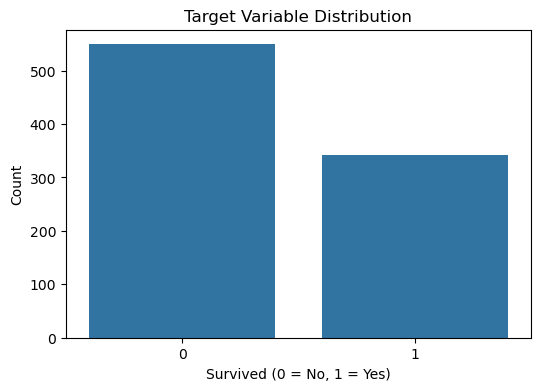

In [32]:
print("\n" + "="*50)
print("TARGET VARIABLE DISTRIBUTION")
print("="*50)

print(df['Survived'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df)

plt.title("Target Variable Distribution")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Count")

plt.show()

#STEP 6: Exploratory Data Analysis (EDA)


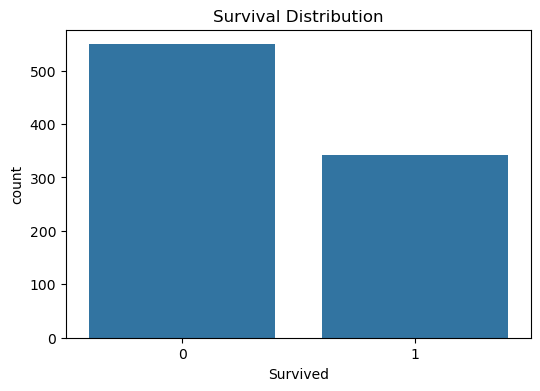

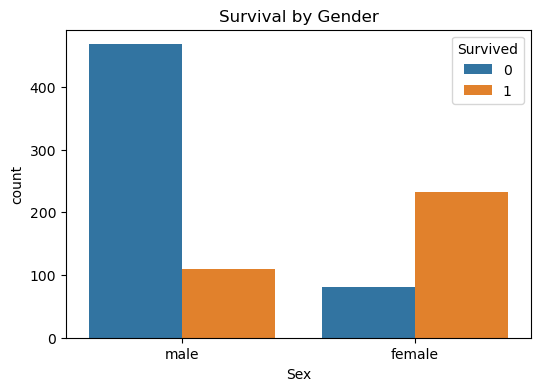

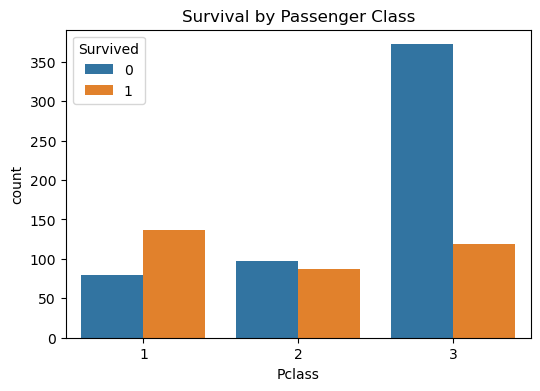

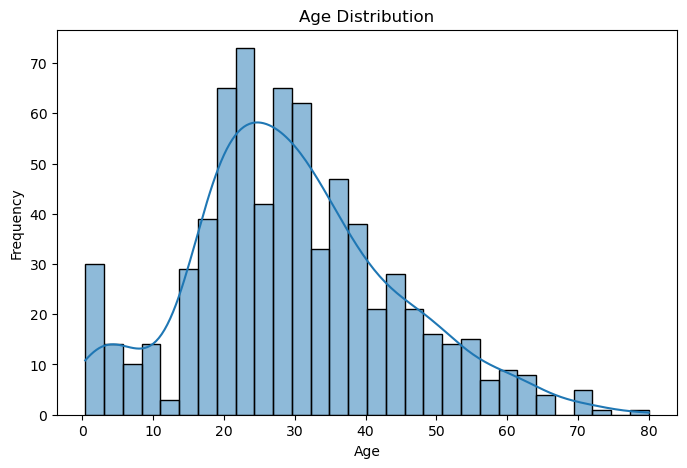

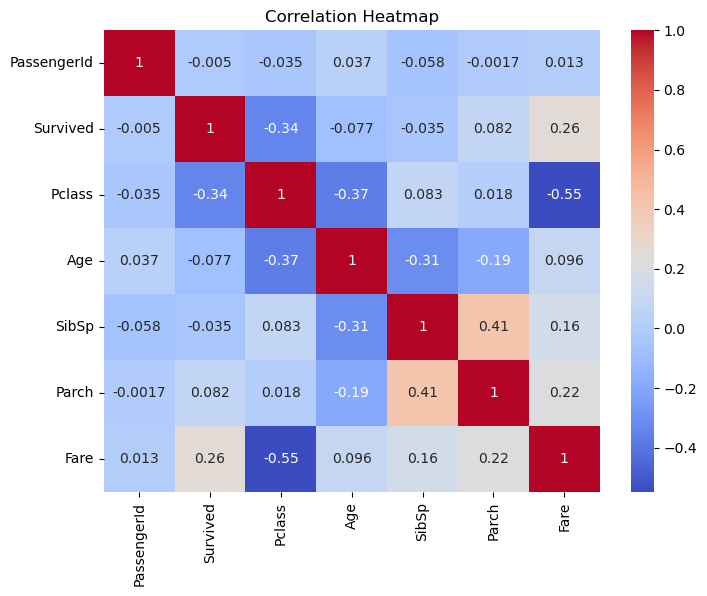

In [33]:
#survival Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Survived',data=df)
plt.title("Survival Distribution")
plt.show()

# Survival by Gender
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Survival by Gender")
plt.show()

# Survival by Passenger Class
plt.figure(figsize=(6,4))
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Survival by Passenger Class")
plt.show()

# Age Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# Correlation Heatmap
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


#STEP 7: Data Cleaning



In [34]:
# Fill missing Age values with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Embarked values with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin column
df.drop('Cabin', axis=1, inplace=True)

print("\n" + "="*50)
print("MISSING VALUES AFTER CLEANING")
print("="*50)
print(df.isnull().sum())



MISSING VALUES AFTER CLEANING
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


#STEP 8: Save Cleaned Dataset


In [35]:
df.to_csv("Titanic_Cleaned.csv", index=False)

print("\nTitanic_Cleaned.csv Saved Successfully")



Titanic_Cleaned.csv Saved Successfully


#STEP 9: Encode Categorical Variables


In [36]:
le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

#STEP 10: Feature Selection


In [37]:
X = df[['Pclass',
        'Sex',
        'Age',
        'SibSp',
        'Parch',
        'Fare',
        'Embarked']]

y = df['Survived']

print("\nFeatures Shape:", X.shape)
print("Target Shape:",y.shape)


Features Shape: (891, 7)
Target Shape: (891,)


#STEP 11: Train-Test Split


In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


Training Data Shape: (712, 7)
Testing Data Shape: (179, 7)


#STEP 12: Train Model


In [39]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("\nModel Training Completed")



Model Training Completed


#STEP 13: Make Predictions


In [40]:
y_pred = model.predict(X_test)


#STEP 14: Evaluate Model


In [41]:
accuracy = accuracy_score(y_test, y_pred)

print("\n" + "="*50)
print("MODEL ACCURACY")
print("="*50)
print(f"Accuracy Score: {accuracy*100:.2f}%")

print("\nCLASSIFICATION REPORT")
print(classification_report(y_test, y_pred))
#prediction sample
print("\nPREDICTION SAMPLE")
sample=pd.DataFrame({'Actual':y_test.values,'Predicted':y_pred})
print(sample.head(10))


MODEL ACCURACY
Accuracy Score: 82.68%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.84      0.89      0.86       110
           1       0.81      0.72      0.76        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.82       179


PREDICTION SAMPLE
   Actual  Predicted
0       0          0
1       0          0
2       1          0
3       0          0
4       1          1
5       1          0
6       1          1
7       0          1
8       0          0
9       0          0


#STEP 15: Confusion Matrix


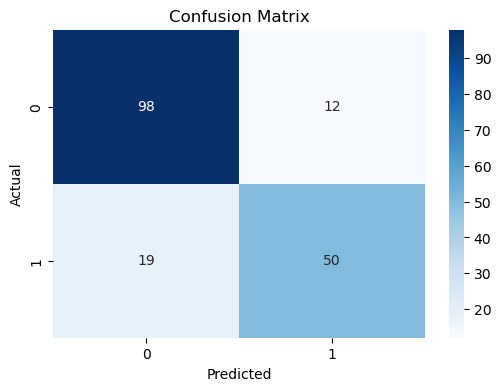

In [42]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#STEP 16: Feature Importance





FEATURE IMPORTANCE
    Feature  Importance
5      Fare    0.270237
1       Sex    0.260625
2       Age    0.250389
0    Pclass    0.092549
3     SibSp    0.050297
4     Parch    0.041084
6  Embarked    0.034820


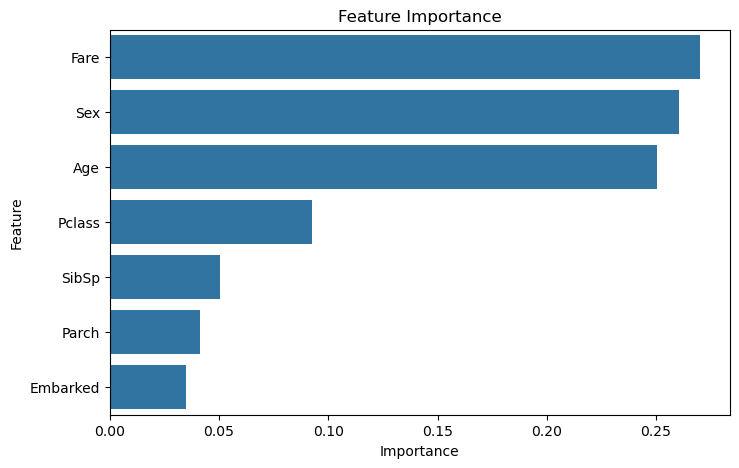

In [43]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFEATURE IMPORTANCE")
print(importance)

plt.figure(figsize=(8,5))
sns.barplot(data=importance,
            x='Importance',
            y='Feature')

plt.title("Feature Importance")
plt.show()

#STEP 17: Project Insights


In [44]:
print("\n" + "="*50)
print("PROJECT INSIGHTS")
print("="*50)

print("1. The dataset contains 891 passenger records and 12 columns.")
print("2. Female passengers had a higher survival rate than male passengers.")
print("3. First-class passengers were more likely to survive than lower-class passengers.")
print("4. Passenger class, gender, age, and fare were important factors affecting survival.")
print("5. The dataset contained missing values in Age, Cabin, and Embarked columns.")
print("6. Missing values were handled using data cleaning techniques.")
print("7. Random Forest Classifier achieved good accuracy in predicting passenger survival.")
print("8. Feature importance analysis showed which factors most influenced survival.")
print("9. The model successfully classified passengers as survived or not survived.")
print("10. Machine Learning can be used to analyze historical data and make predictions.")


PROJECT INSIGHTS
1. The dataset contains 891 passenger records and 12 columns.
2. Female passengers had a higher survival rate than male passengers.
3. First-class passengers were more likely to survive than lower-class passengers.
4. Passenger class, gender, age, and fare were important factors affecting survival.
5. The dataset contained missing values in Age, Cabin, and Embarked columns.
6. Missing values were handled using data cleaning techniques.
7. Random Forest Classifier achieved good accuracy in predicting passenger survival.
8. Feature importance analysis showed which factors most influenced survival.
9. The model successfully classified passengers as survived or not survived.
10. Machine Learning can be used to analyze historical data and make predictions.
